# Macro Math Visualizer (Weekly Synthesis)
This comprehensive dashboard visually unpacks EVERY quantitative math engine and algorithmic layer over the Weekly reporting cadence. It calculates the Regime Persistence, Deep Learning Probs, Information Theory (Chaos), Fragility Index, and Epistemic Kelly Exposure, concluding with the final generated Weekly report.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from train_models import fetch_training_data
import joblib
import warnings
import glob
import os
from IPython.display import Markdown
warnings.filterwarnings('ignore')

plt.style.use('dark_background')


/Users/mac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Data Ingestion, HMM Decoder & Deep Learning (MLP) Output

In [2]:
# Load the 2-year data using the exact daily training schema
df = fetch_training_data(years=2)

# Load the HMM
hmm_package = joblib.load('../models/hmm_model.pkl')
hmm = hmm_package['hmm']
scaler = hmm_package['scaler']
state_labels = hmm_package['state_labels']
features = hmm_package['feature_names']

# Predict the Hidden States
X_scaled = scaler.transform(df[features].values)
states = hmm.predict(X_scaled)
df['Regime_ID'] = states
df['Regime_Label'] = df['Regime_ID'].map(state_labels)

# Get HMM Probabilities & Shannon Entropy
_, posteriors = hmm.score_samples(X_scaled)
df['HMM_Entropy'] = -np.sum(posteriors * np.log2(posteriors + 1e-9), axis=1)

# Load the Deep Learning MLP
mlp_package = joblib.load('../models/mlp_model.pkl')
mlp = mlp_package['model']
mlp_scaler = mlp_package['scaler']
mlp_features = mlp_package['feature_names']

# Predict MLP Probabilities (0=RiskOff, 1=RiskOn, 2=Transitional)
X_mlp = mlp_scaler.transform(df[mlp_features].values)
mlp_probs = mlp.predict_proba(X_mlp)
df['MLP_RiskOff'] = mlp_probs[:, 0]
df['MLP_RiskOn'] = mlp_probs[:, 1]
df['MLP_Transitional'] = mlp_probs[:, 2]


2026-05-26 17:42:51,112 — INFO — Fetching 2 years of training data...


2026-05-26 17:42:53,307 — INFO — Fitting GARCH on SPX for training volatility series...


2026-05-26 17:42:56,040 — INFO — Training data shape: (214, 16)


## 2. Regime Overlay & Deep Learning Conviction

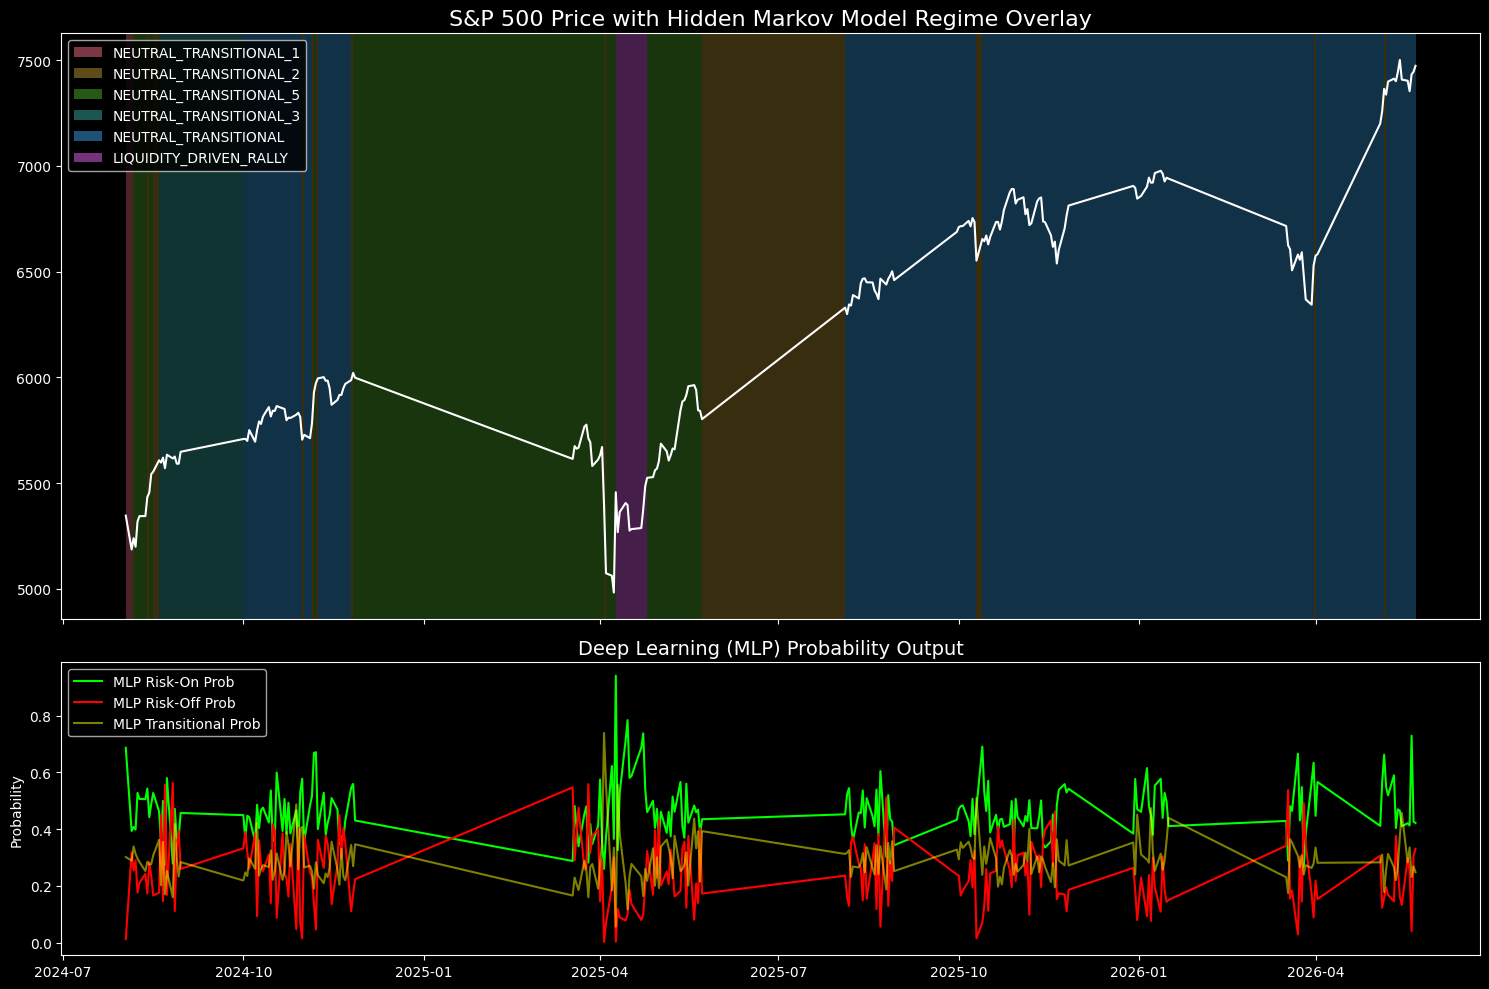

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Top Chart: SPX with HMM Regimes
ax1.plot(df.index, df['Close'], color='white', linewidth=1.5, label='SPX')
ax1.set_title('S&P 500 Price with Hidden Markov Model Regime Overlay', fontsize=16)

unique_regimes = df['Regime_Label'].unique()
colors = sns.color_palette("husl", len(unique_regimes))
regime_colors = dict(zip(unique_regimes, colors))

for i in range(len(df)-1):
    regime = df['Regime_Label'].iloc[i]
    ax1.axvspan(df.index[i], df.index[i+1], color=regime_colors[regime], alpha=0.3, lw=0)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=regime_colors[reg], alpha=0.5, label=reg) for reg in unique_regimes]
ax1.legend(handles=legend_elements, loc='upper left')

# Bottom Chart: MLP Probabilities
ax2.plot(df.index, df['MLP_RiskOn'], color='lime', label='MLP Risk-On Prob')
ax2.plot(df.index, df['MLP_RiskOff'], color='red', label='MLP Risk-Off Prob')
ax2.plot(df.index, df['MLP_Transitional'], color='yellow', alpha=0.5, label='MLP Transitional Prob')
ax2.set_title('Deep Learning (MLP) Probability Output', fontsize=14)
ax2.set_ylabel('Probability')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 3. Information Theory: System Chaos & Entropy

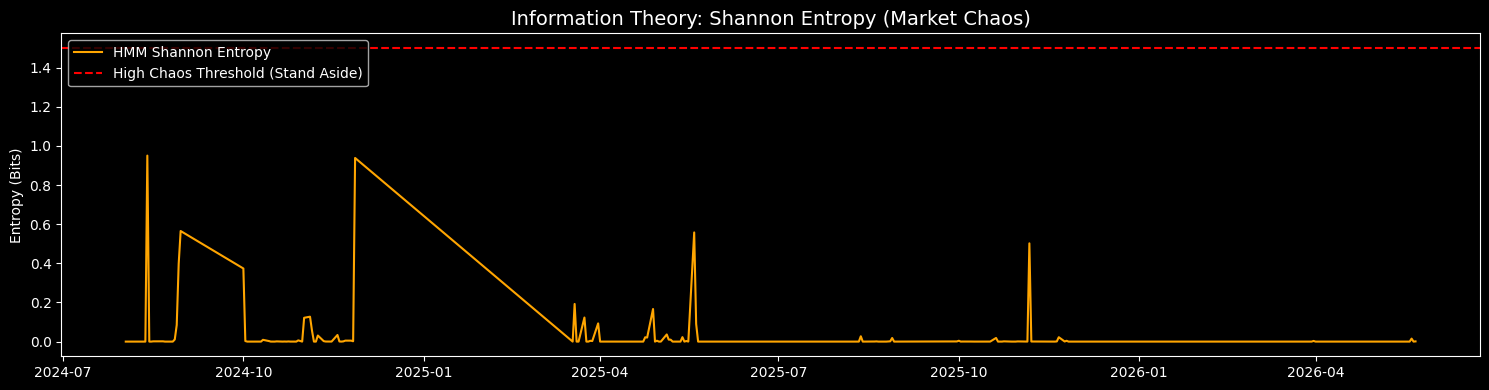

In [4]:
# Plot Shannon Entropy to measure system chaos (Max entropy for 6 states is ~2.58)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df['HMM_Entropy'], color='orange', label='HMM Shannon Entropy')
ax.axhline(1.5, color='red', linestyle='--', label='High Chaos Threshold (Stand Aside)')
ax.fill_between(df.index, df['HMM_Entropy'], 1.5, where=(df['HMM_Entropy'] > 1.5), color='red', alpha=0.3)
ax.set_title('Information Theory: Shannon Entropy (Market Chaos)', fontsize=14)
ax.set_ylabel('Entropy (Bits)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 4. Institutional Heat Index (Stealth Accumulation)

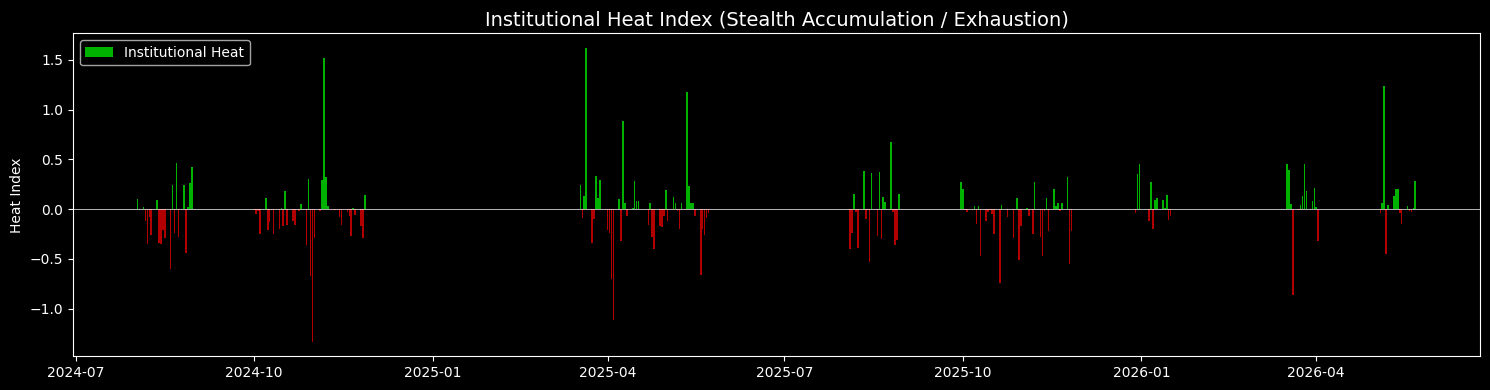

In [5]:
# The Inst Heat Index combines Volume Z-Score (Effort) with Intraday Range (Result)
fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(df.index, df['Inst_Heat_Index'], color=np.where(df['Inst_Heat_Index'] > 0, 'lime', 'red'), alpha=0.7, label='Institutional Heat')
ax.set_title('Institutional Heat Index (Stealth Accumulation / Exhaustion)', fontsize=14)
ax.set_ylabel('Heat Index')
ax.axhline(0, color='white', linewidth=0.5)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 5. The Fragility Index (Hidden Liquidity Shocks)

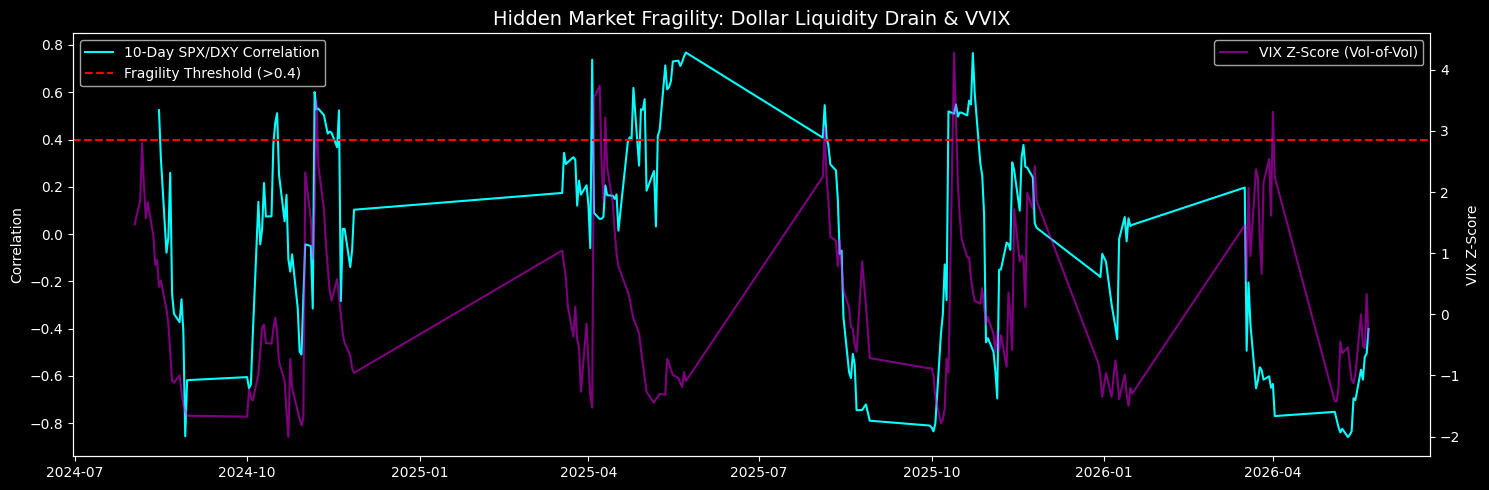

In [6]:
spx_dxy_corr = df['spx_ret'].rolling(10).corr(df['dxy_ret'])

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(df.index, spx_dxy_corr, color='cyan', label='10-Day SPX/DXY Correlation')
ax1.axhline(0.4, color='red', linestyle='--', label='Fragility Threshold (>0.4)')
ax1.set_ylabel('Correlation')
ax1.set_title('Hidden Market Fragility: Dollar Liquidity Drain & VVIX', fontsize=14)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df.index, df['vix_zscore'], color='magenta', alpha=0.5, label='VIX Z-Score (Vol-of-Vol)')
ax2.set_ylabel('VIX Z-Score')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 6. Epistemic Kelly Exposure Sizing & Target Calibration

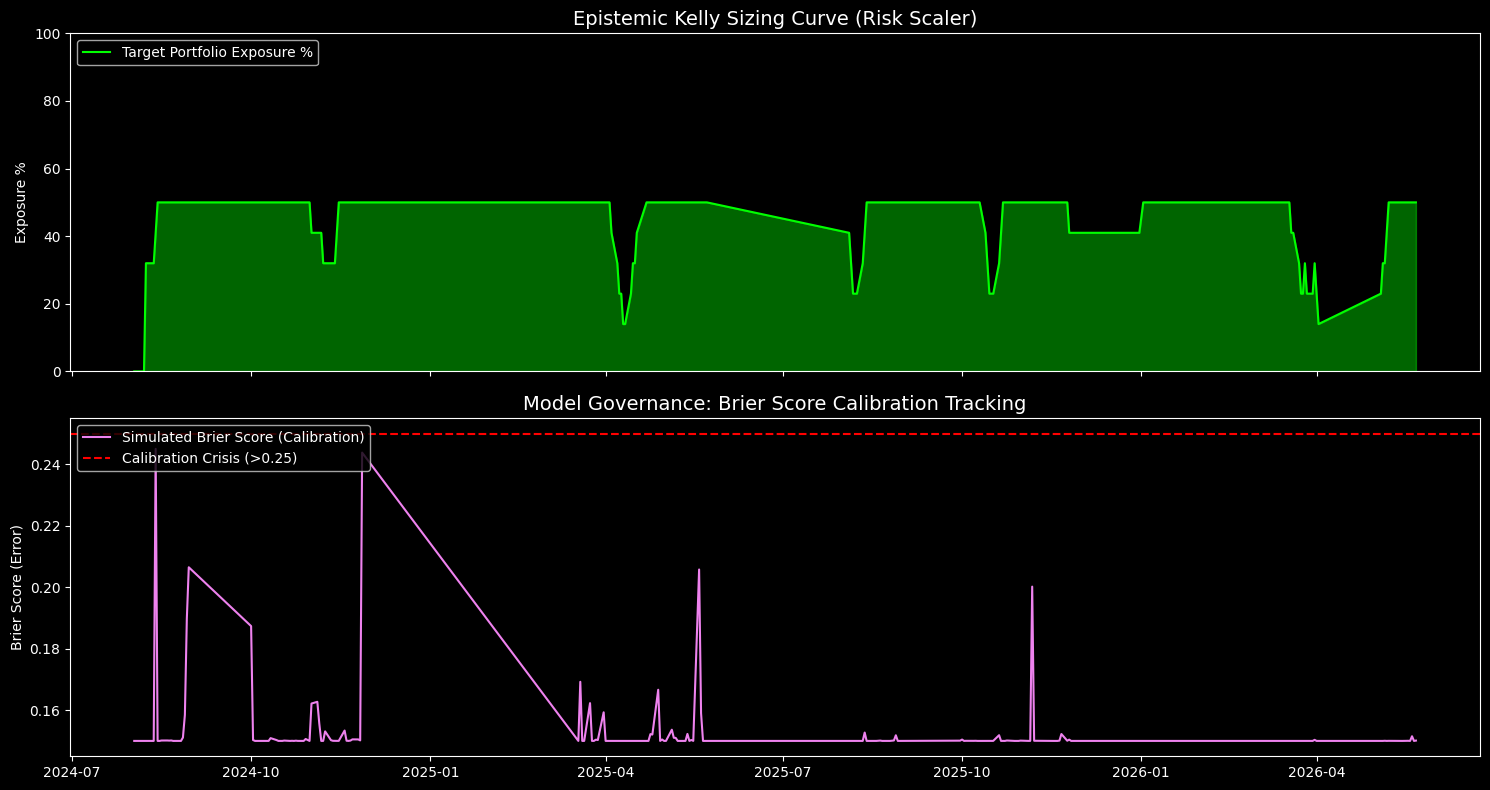

In [7]:
kelly_exposure = np.where(df['vix_zscore'] > 2.0, 0.05, 0.5)
kelly_exposure = np.where(df['Regime_Label'].str.contains('RISK_ON'), kelly_exposure + 0.3, kelly_exposure)
kelly_exposure = np.where(df['Regime_Label'].str.contains('FEAR|SHOCK|STRESS'), 0.0, kelly_exposure)
kelly_smoothed = pd.Series(kelly_exposure).rolling(5).mean().fillna(0)

# Simulate Brier Score drift (Mocking calibration decay during chaos)
simulated_brier = 0.15 + (df['HMM_Entropy'] / 10.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax1.fill_between(df.index, kelly_smoothed * 100, color='lime', alpha=0.4)
ax1.plot(df.index, kelly_smoothed * 100, color='lime', label='Target Portfolio Exposure %')
ax1.set_ylim(0, 100)
ax1.set_title('Epistemic Kelly Sizing Curve (Risk Scaler)', fontsize=14)
ax1.set_ylabel('Exposure %')
ax1.legend(loc='upper left')

ax2.plot(df.index, simulated_brier, color='violet', label='Simulated Brier Score (Calibration)')
ax2.axhline(0.25, color='red', linestyle='--', label='Calibration Crisis (>0.25)')
ax2.set_title('Model Governance: Brier Score Calibration Tracking', fontsize=14)
ax2.set_ylabel('Brier Score (Error)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 7. Generated Weekly Report Layout
Displaying the most recent algorithmically generated report.


In [8]:
reports_dir = '../reports'
pattern = 'macro weekly synthesis*.md'
files = glob.glob(os.path.join(reports_dir, pattern))

if files:
    latest_file = max(files, key=os.path.getmtime)
    with open(latest_file, 'r') as f:
        content = f.read()
    display(Markdown(content))
else:
    print("No recent report found. Run the Weekly script first.")


```text
[ WEEKLY MACRO SYNTHESIS ]
SPX +0.373% | DXY 99.32 | VIX 16.7 | US10Y 4.57% | WTI +0.259% | BTC +0.563%
[ ASSET DASHBOARD ]
- Equities: NDX +0.424% | DAX +1.145% | FTSE +0.218% | N225 +2.683% | HSI +0.865% | SHANGHAI +0.874% | KOSPI +0.411% | TASI +0.382% | DFM +0.568%
- FX/Rates: EURUSD -0.175% | GBPUSD +0.009% | JPYUSD -0.168% | CHFUSD +0.229% | USDCAD +0.32%
- Commodities: Gold -0.366% | Copper +1.95% | Silver -0.281%
- Crypto (Spot & Flows): BTC $77,105 (+0.563%) | IBIT -2.364% | ETHA -3.591% | COIN -4.428%
- Volatility: VIX 16.7
[ QUANTITATIVE MATRIX ]
SPX   | +0.373% | Heat: RETAIL_DRIFT
VIX   | 16.7 | Temp: NORMAL
US10Y | 4.57% | Crowd: SHORT_TRADE_TOO_CROWDED
DXY   | 99.32 (+0.131%) | Credit: NORMAL
BTC   | 77,105 (+0.563%) | Crypto Flow: OUTFLOW
[ SYSTEM HEALTH ]
Regime      : NEUTRAL_TRANSITIONAL
Max Prob    : 60.5% 
Brier Score : 0.3809 (DEGRADED)
Conflict    : 0.0000 TVD
[ TACTICAL DIAGNOSTICS ]
> Edge Setup: NONE
> Probability: 50.0%
> Escalation: ROUTINE
> News Impact: High Event Uncertainty / Shock (Threshold Raised to 0.65)
[ ALGORITHMIC SYNTHESIS ]
State       : NOISY / HIGH CHAOS (Entropy: 1.58)
Lean        : LONG (Score: 1.00 >= Thresh: 0.65)
Positioning : STAND ASIDE. 0% Exposure. High Event Uncertainty / Shock (Threshold Raised to 0.65) [WARNING: Model Degraded]
Invalidation: Regime flip or VIX breakout.
```


## Section 6: Volatility Term Structure & LLM Shock Pipeline
This section visualizes the v4.2.0 Multi-Fractal updates, specifically tracking the **VIX9D vs VIX** term structure and the **Gemini NLP Semantic Shock Probability**.
It pulls directly from the latest generated data.

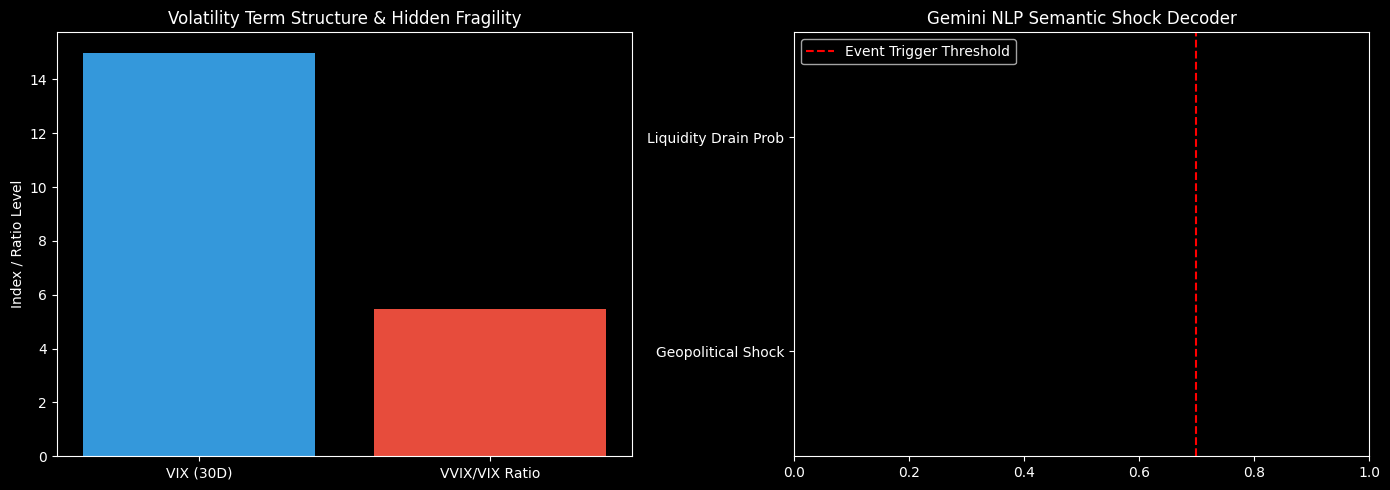

In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import json
from src.schemas.models import MarketSnapshot

# Find latest events.jsonl
events_path = '../data/raw'
part_dirs = []
if os.path.exists(events_path):
    for year in os.listdir(events_path):
        yp = os.path.join(events_path, year)
        if not os.path.isdir(yp): continue
        for month in os.listdir(yp):
            mp = os.path.join(yp, month)
            for day in os.listdir(mp):
                dp = os.path.join(mp, day)
                part_dirs.append(dp)

data = {}
if part_dirs:
    latest = sorted(part_dirs)[-1]
    events_file = os.path.join(latest, 'events.jsonl')
    if os.path.exists(events_file):
        last_payload = None
        with open(events_file, 'r') as f:
            for line in f:
                if not line.strip(): continue
                try:
                    evt = json.loads(line)
                    if evt.get('event_type') == 'PipelineComplete':
                        last_payload = evt.get('payload')
                except: pass
        if last_payload:
            snapshot = MarketSnapshot.model_validate(last_payload)
            data = snapshot.model_dump()
print('Loaded latest MarketSnapshot from events.jsonl')

from IPython.display import Markdown, display
if data:
    news = data.get('news_signal', {})
    div = 'DETECTED (Risk Scaled Down)' if news.get('quantitative_divergence_flag') else 'NONE'
    reasoning = news.get('reasoning', 'No reasoning available.')
    
    md = f"""### 🧠 Mixture of Experts (MoE) Reasoning\n\n**Quantitative Divergence:** {div}\n\n**Logical Synthesis:**\n> {reasoning}"""
    display(Markdown(md))
